In [3]:
#PART A : Perform Exploratory Data Analysis (EDA)
#1. Load the data
#2. Understand the data
#3. Visualize the data

import pandas as pd  # read and work with datasets(csv files)
import numpy as np   # Used for Numerical calculations and arrays
import matplotlib.pyplot as plt  #we'll use it to make graph and visulize the data


In [4]:
import pandas as pd

df = pd.read_csv("forestfires.csv")
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [5]:
df.shape


(515, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515 entries, 0 to 514
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       515 non-null    int64  
 1   Y       515 non-null    int64  
 2   month   515 non-null    object 
 3   day     515 non-null    object 
 4   FFMC    515 non-null    float64
 5   DMC     515 non-null    float64
 6   DC      515 non-null    float64
 7   ISI     515 non-null    float64
 8   temp    515 non-null    float64
 9   RH      515 non-null    int64  
 10  wind    515 non-null    float64
 11  rain    515 non-null    float64
 12  area    515 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.4+ KB


In [7]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000,515.000000
mean,4.660194,4.295146,90.664272,110.925437,548.626019,9.039417,18.888738,44.330097,4.015728,0.021748,12.536485
std,2.312853,1.220080,5.508720,63.895656,247.753859,4.554604,5.800546,16.334531,1.794882,0.296531,63.318585
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,69.150000,439.300000,6.500000,15.550000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,141.850000,713.900000,10.900000,22.800000,53.000000,4.900000,0.000000,6.555000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


In [8]:
df["month"].value_counts()
# Most forest fires occurred in August and September
# Very few fires occurred in January and May 

aug    183
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
Name: month, dtype: int64

In [9]:
df["day"].value_counts()
# The largest number of fires occurred on Sunday and Wednesday from fake data 
#Unlike the month variable, the counts are fairly balanced across the days of the week

sun    95
fri    85
sat    84
mon    74
tue    63
thu    61
wed    53
Name: day, dtype: int64

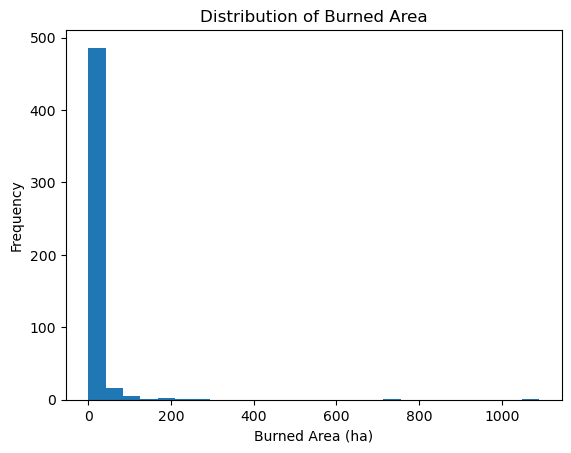

In [10]:
plt.hist(df["area"], bins=26)
plt.xlabel("Burned Area (ha)")
plt.ylabel("Frequency")
plt.title("Distribution of Burned Area")
plt.show()

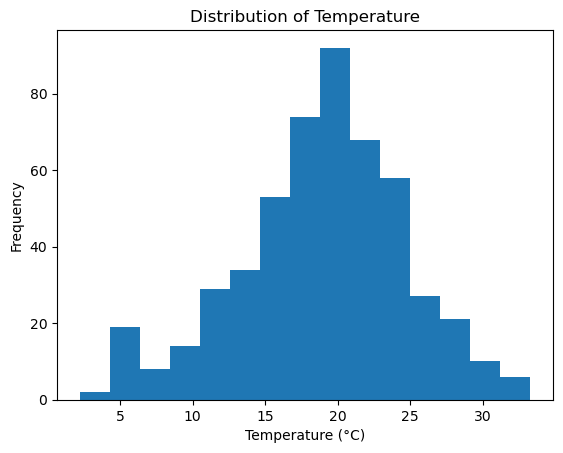

In [11]:
plt.hist(df["temp"], bins=15)
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.title("Distribution of Temperature")
plt.show()
#here comparing with describe() , mean~ median we expect the histogram to be roughly symmetrical
#No Extreme outliars are visible

array([[<AxesSubplot:title={'center':'X'}>,
        <AxesSubplot:title={'center':'Y'}>,
        <AxesSubplot:title={'center':'FFMC'}>],
       [<AxesSubplot:title={'center':'DMC'}>,
        <AxesSubplot:title={'center':'DC'}>,
        <AxesSubplot:title={'center':'ISI'}>],
       [<AxesSubplot:title={'center':'temp'}>,
        <AxesSubplot:title={'center':'RH'}>,
        <AxesSubplot:title={'center':'wind'}>],
       [<AxesSubplot:title={'center':'rain'}>,
        <AxesSubplot:title={'center':'area'}>, <AxesSubplot:>]],
      dtype=object)

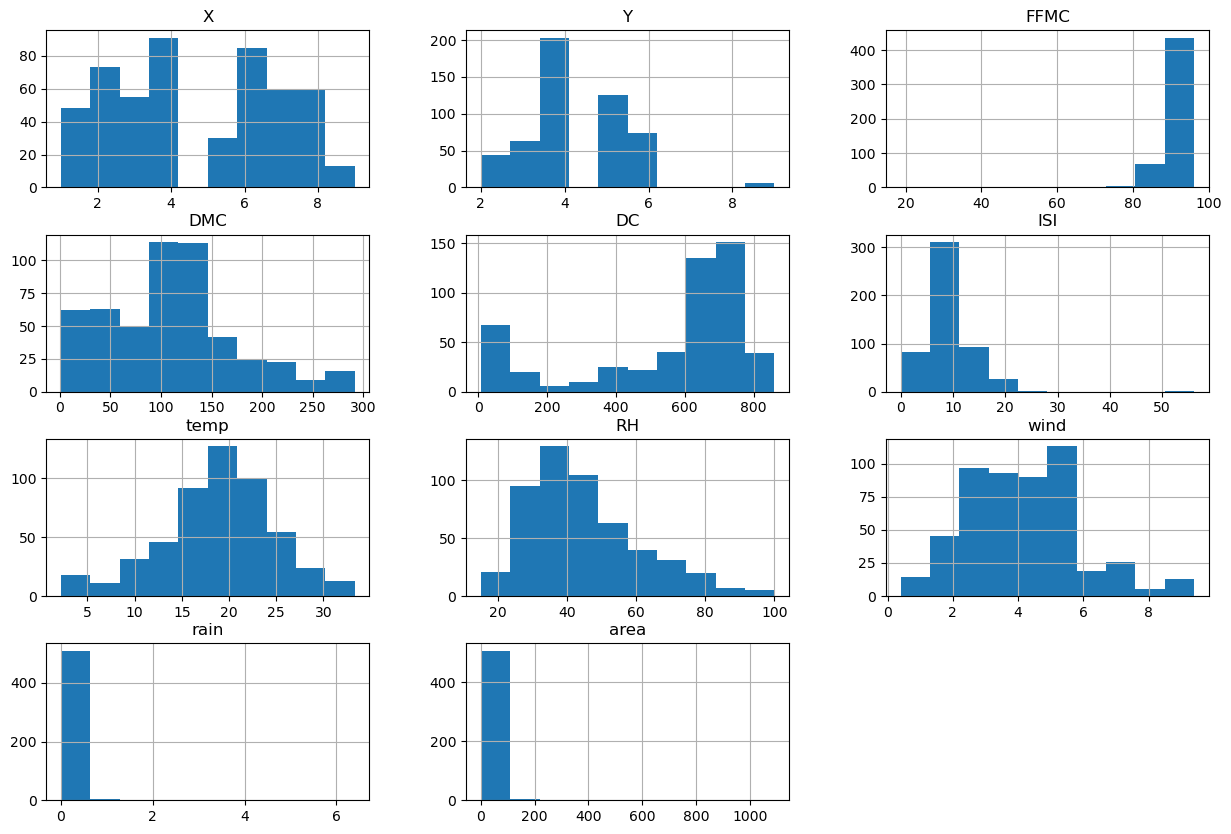

In [12]:
df.hist(figsize=(15,10))

In [13]:
numeric_df = df.select_dtypes(include="number")
numeric_df.corr()
# Correlation matrix: Ignore the diagonal because these are always 1, because every vriable is perfectly correlated with itself.
# Correlation r sign tells the direction. 
#Positive -> Both Increases together 
#Negative -> One Increases while the other decreses
# All predictors correlations with area are very close to 0. This is very weak positive correlation.
# There are no strong linear relationships between any single predictor and the burned area. This is an important findings suggests that, The burned area is not strongly explained by any one variable alone.
#A multiple regression model may still find useful combinations of variables, but simple linear relationships are weak. 

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
X,1.000000,0.538906,-0.019431,-0.050345,-0.085384,0.008957,-0.053696,0.087842,0.017787,0.065829,0.056553
Y,0.538906,1.000000,-0.052269,-0.003039,-0.108294,-0.026815,-0.034387,0.064217,-0.021580,0.033848,0.029100
FFMC,-0.019431,-0.052269,1.000000,0.378693,0.325751,0.528791,0.429282,-0.305497,-0.027642,0.056668,0.038777
DMC,-0.050345,-0.003039,0.378693,1.000000,0.680606,0.302308,0.465925,0.072749,-0.105586,0.075052,0.066484
DC,-0.085384,-0.108294,0.325751,0.680606,1.000000,0.224730,0.494185,-0.041828,-0.203398,0.035773,0.047327
ISI,0.008957,-0.026815,0.528791,0.302308,0.224730,1.000000,0.393183,-0.136064,0.108217,0.067587,0.009101
temp,-0.053696,-0.034387,0.429282,0.465925,0.494185,0.393183,1.000000,-0.530134,-0.227848,0.069705,0.091672
RH,0.087842,0.064217,-0.305497,0.072749,-0.041828,-0.136064,-0.530134,1.000000,0.070176,0.099653,-0.073749
wind,0.017787,-0.021580,-0.027642,-0.105586,-0.203398,0.108217,-0.227848,0.070176,1.000000,0.061205,0.011082
rain,0.065829,0.033848,0.056668,0.075052,0.035773,0.067587,0.069705,0.099653,0.061205,1.000000,-0.007059


In [14]:
'''sns.heatmap(
    numeric_df.corr(),# The correlation matrix you already calculated
    annot=True, #write the correlationnumbers inside each square
    cmap="coolwarm", # chooses the color scheme
    fmt=".2f"   # Display 2 decimal places '''

'sns.heatmap(\n    numeric_df.corr(),# The correlation matrix you already calculated\n    annot=True, #write the correlationnumbers inside each square\n    cmap="coolwarm", # chooses the color scheme\n    fmt=".2f"   # Display 2 decimal places '

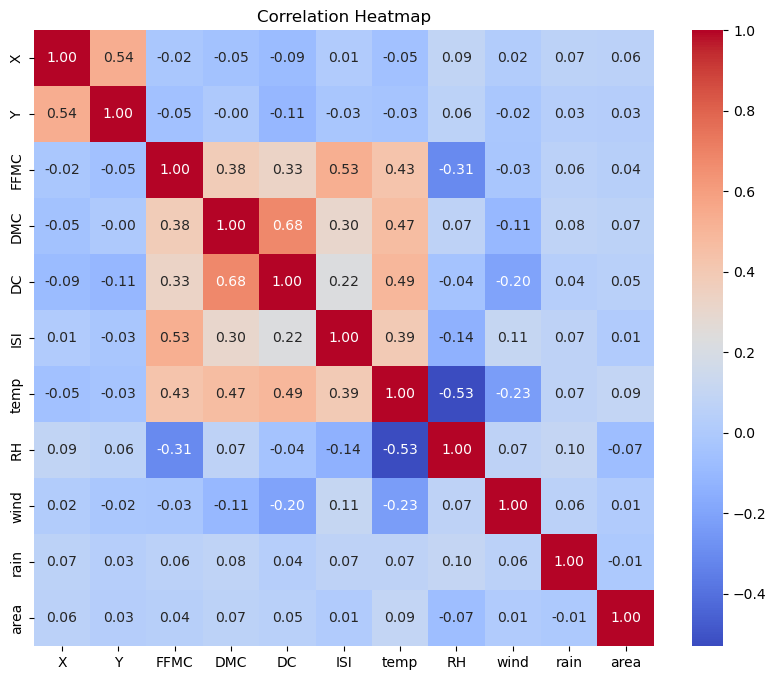

In [15]:
import seaborn as sns
#Create figure that is 10 inches wide and 8 inches tall
plt.figure(figsize=(10,8))

#Create heatmap
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


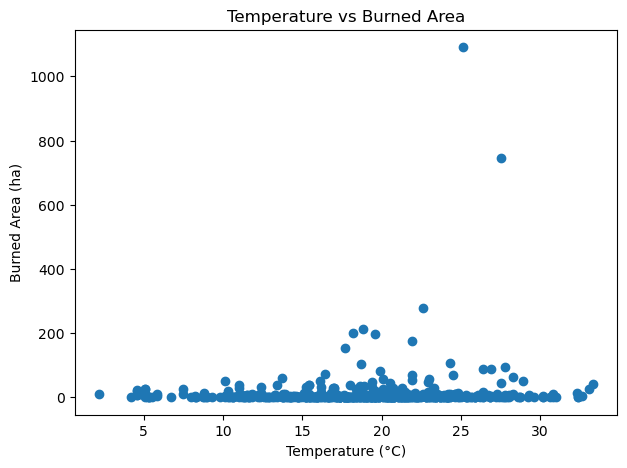

In [16]:
plt.figure(figsize=(7,5))

plt.scatter(df["temp"], df["area"])

plt.xlabel("Temperature (°C)")
plt.ylabel("Burned Area (ha)")
plt.title("Temperature vs Burned Area")

plt.show()

In [17]:
# Part B TRANSFORM
import numpy as np

df["log_area"] = np.log(df["area"] + 1)
df[["area", "log_area"]].head(10)

,area,log_area
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0
5,0.0,0.0
6,0.0,0.0
7,0.0,0.0
8,0.0,0.0
9,0.0,0.0


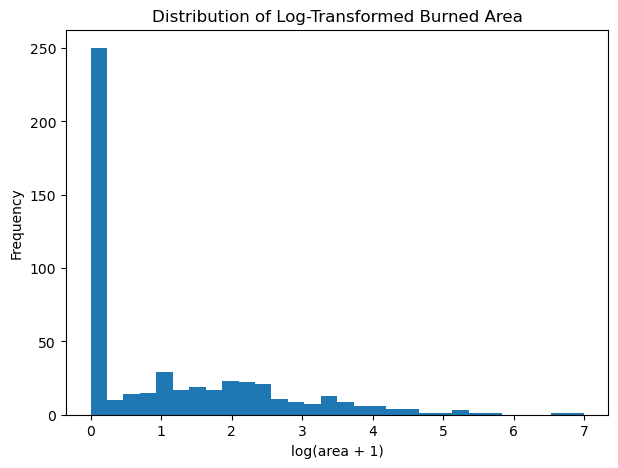

In [18]:
plt.figure(figsize=(7,5))

plt.hist(df["log_area"], bins=30)

plt.xlabel("log(area + 1)")
plt.ylabel("Frequency")
plt.title("Distribution of Log-Transformed Burned Area")

plt.show()

In [19]:
df[df["area"] > 0][["area", "log_area"]].head(10)

,area,log_area
138,0.36,0.307485
139,0.43,0.357674
140,0.47,0.385262
141,0.55,0.438255
142,0.61,0.476234
143,0.71,0.536493
144,0.77,0.570980
145,0.90,0.641854
146,0.95,0.667829
147,0.96,0.672944


In [20]:
df["area"].skew()

13.079309165566112

In [21]:
df["log_area"].skew()

1.2118490335117353

In [22]:
df.isnull().sum()

X           0
Y           0
month       0
day         0
FFMC        0
DMC         0
DC          0
ISI         0
temp        0
RH          0
wind        0
rain        0
area        0
log_area    0
dtype: int64

In [23]:
#PART C Fit 10 simple regressions
# we will use statsmodels and not going to use scikit-learn because statsmodels gives
# coefficients, p-values, Confidence intervals, R^2, F-statistics, Residual information

import statsmodels.formula.api as smf
# Ordinary Least Squares
model_temp = smf.ols("log_area ~ temp", data=df).fit()
model_temp.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.039
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.309
Time:                        14:24:15   Log-Likelihood:                -898.75
No. Observations:                 515   AIC:                             1801.
Df Residuals:                     513   BIC:                             1810.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.9019      0.209      4.324      0.000       0.492       1.312
temp           0.0108      0.011      1.019      0.309      -0.010       0.032
==============================================================================
Omnibus:                       91.490   Durbin-Watson:                   0.899
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              138.002
Skew:                           1.195   Prob(JB):                     1.08e-30
Kurtosis:                       3.847   Cond. No.                         67.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
predictors = ["X", "Y", "FFMC", "DMC", "DC", "ISI",
              "temp", "RH", "wind", "rain"]

results = []

for predictor in predictors:

    formula = f"log_area ~ {predictor}"

    model = smf.ols(formula, data=df).fit()

    results.append({
        "Predictor": predictor,
        "Coefficient": model.params[predictor],
        "P-value": model.pvalues[predictor],
        "R-squared": model.rsquared,
        "Significant": "Yes" if model.pvalues[predictor] < 0.05 else "No"
    })

results_df = pd.DataFrame(results)

results_df



,Predictor,Coefficient,P-value,R-squared,Significant
0,X,0.033184,0.210447,0.003056,No
1,Y,0.023224,0.644040,0.000416,No
2,FFMC,0.010882,0.328124,0.001864,No
3,DMC,0.001264,0.187575,0.003383,No
4,DC,0.000350,0.157545,0.003890,No
5,ISI,-0.003541,0.792563,0.000135,No
6,temp,0.010762,0.308510,0.002021,No
7,RH,-0.004465,0.234047,0.002759,No
8,wind,0.051410,0.132019,0.004417,No
9,rain,0.111598,0.589445,0.000568,No


In [25]:
''' 
Ten simple linear regression models were fitted, 
each using one predictor to predict the log-transformed burned area. 
None of the predictors showed a statistically significant association with the response (all p-values > 0.05). 
In addition, all models had very low R² values (less than 0.5%), indicating that no single predictor explained
a meaningful proportion of the variation in the burned area.

'''

' \nTen simple linear regression models were fitted, \neach using one predictor to predict the log-transformed burned area. \nNone of the predictors showed a statistically significant association with the response (all p-values > 0.05). \nIn addition, all models had very low R² values (less than 0.5%), indicating that no single predictor explained\na meaningful proportion of the variation in the burned area.\n\n'

In [26]:
#Part D Fit one multiple regression
full_model = smf.ols(
    "log_area ~ X + Y + FFMC + DMC + DC + ISI + temp + RH + wind + rain",
    data=df
).fit()

full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.170
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.309
Time:                        14:24:15   Log-Likelihood:                -893.36
No. Observations:                 515   AIC:                             1809.
Df Residuals:                     504   BIC:                             1855.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2185      1.380      0.158      0.874      -2.493       2.931
X              0.0421      0.032      1.332      0.184      -0.020       0.104
Y             -0.0062      0.060     -0.104      0.917      -0.125       0.112
FFMC           0.0068      0.014      0.470      0.638      -0.022       0.035
DMC            0.0011      0.001      0.724      0.469      -0.002       0.004
DC             0.0003      0.000      0.937      0.349      -0.000       0.001
ISI           -0.0227      0.017     -1.349      0.178      -0.056       0.010
temp          -0.0010      0.017     -0.058      0.954      -0.035       0.033
RH            -0.0061      0.005     -1.180      0.239      -0.016       0.004
wind           0.0729      0.036      2.001      0.046       0.001       0.144
rain           0.0880      0.211      0.417      0.677      -0.327       0.503
==============================================================================
Omnibus:                       87.631   Durbin-Watson:                   0.912
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.831
Skew:                           1.162   Prob(JB):                     6.42e-29
Kurtosis:                       3.806   Cond. No.                     1.40e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [27]:
'''


A multiple linear regression model was fitted using all predictors. 
The overall model was not statistically significant (F-test p = 0.309), 
and the model explained only 2.3% of the variation in the log-transformed burned area (R² = 0.023). 
Among all predictors, wind was the only statistically significant variable (β = 0.0729, p = 0.046), 
indicating that, after adjusting for the other predictors, 
higher wind speed was associated with a small increase in the log-transformed burned area. 
All other predictors had p-values greater than 0.05.

'''

'\n\n\nA multiple linear regression model was fitted using all predictors. \nThe overall model was not statistically significant (F-test p = 0.309), \nand the model explained only 2.3% of the variation in the log-transformed burned area (R² = 0.023). \nAmong all predictors, wind was the only statistically significant variable (β = 0.0729, p = 0.046), \nindicating that, after adjusting for the other predictors, \nhigher wind speed was associated with a small increase in the log-transformed burned area. \nAll other predictors had p-values greater than 0.05.\n\n'

In [28]:
#Part_e: Build "reasonably good" multiple regression model
predictors = ["X", "Y", "FFMC", "DMC", "DC", "ISI",
              "temp", "RH", "wind", "rain"]

while len(predictors) > 1:

    formula = "log_area ~ " + " + ".join(predictors)

    model = smf.ols(formula, data=df).fit()

    p_values = model.pvalues.drop("Intercept")

    max_p = p_values.max()

    if max_p < 0.05:
        break

    worst_predictor = p_values.idxmax()

    print("Removing:", worst_predictor)

    predictors.remove(worst_predictor)

print("\nFinal Predictors:", predictors)

final_formula = "log_area ~ " + " + ".join(predictors)
final_model = smf.ols(final_formula, data=df).fit()

print(final_model.summary())
    

Removing: temp
Removing: Y
Removing: rain
Removing: FFMC
Removing: DMC
Removing: ISI
Removing: RH
Removing: X
Removing: DC

Final Predictors: ['wind']
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     2.276
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.132
Time:                        14:24:15   Log-Likelihood:                -898.13
No. Observations:                 515   AIC:                             1800.
Df Residuals:                     513   BIC:                             1809.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|     

In [29]:
# Removed temp, because Temperature had the highest p-value (0.954), 
#indicating that it did not contribute significantly to the model
model2 = smf.ols(
"log_area ~ X + Y + FFMC + DMC + DC + ISI + RH + wind + rain",
data=df).fit()

model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.302
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.233
Time:                        14:24:16   Log-Likelihood:                -893.36
No. Observations:                 515   AIC:                             1807.
Df Residuals:                     505   BIC:                             1849.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1955      1.320      0.148      0.882      -2.399       2.790
X              0.0421      0.032      1.332      0.183      -0.020       0.104
Y             -0.0063      0.060     -0.105      0.916      -0.124       0.112
FFMC           0.0068      0.014      0.473      0.636      -0.021       0.035
DMC            0.0010      0.001      0.743      0.458      -0.002       0.004
DC             0.0003      0.000      0.950      0.342      -0.000       0.001
ISI           -0.0230      0.016     -1.423      0.155      -0.055       0.009
RH            -0.0059      0.004     -1.451      0.147      -0.014       0.002
wind           0.0734      0.035      2.069      0.039       0.004       0.143
rain           0.0863      0.209      0.413      0.680      -0.324       0.497
==============================================================================
Omnibus:                       87.526   Durbin-Watson:                   0.912
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.604
Skew:                           1.161   Prob(JB):                     7.19e-29
Kurtosis:                       3.803   Cond. No.                     1.34e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.34e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [30]:
# Remove Y
model3 = smf.ols(
"log_area ~ X + FFMC + DMC + DC + ISI + RH + wind + rain",
data=df).fit()

model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.023
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.466
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.167
Time:                        14:24:16   Log-Likelihood:                -893.37
No. Observations:                 515   AIC:                             1805.
Df Residuals:                     506   BIC:                             1843.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1691      1.295      0.131      0.896      -2.375       2.713
X              0.0403      0.027      1.513      0.131      -0.012       0.093
FFMC           0.0069      0.014      0.478      0.633      -0.021       0.035
DMC            0.0010      0.001      0.736      0.462      -0.002       0.004
DC             0.0003      0.000      0.974      0.331      -0.000       0.001
ISI           -0.0230      0.016     -1.423      0.155      -0.055       0.009
RH            -0.0059      0.004     -1.451      0.147      -0.014       0.002
wind           0.0736      0.035      2.079      0.038       0.004       0.143
rain           0.0863      0.209      0.413      0.679      -0.324       0.496
==============================================================================
Omnibus:                       87.694   Durbin-Watson:                   0.912
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.959
Skew:                           1.163   Prob(JB):                     6.02e-29
Kurtosis:                       3.806   Cond. No.                     1.32e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.32e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [31]:
# Remove Rain
# Since rain has the highest p-value(0.679), we'll remove it.
model4 = smf.ols(
"log_area ~ X + FFMC + DMC + DC + ISI + RH + wind",data=df).fit()
 
model4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     1.654
Date:                Thu, 09 Jul 2026   Prob (F-statistic):              0.118
Time:                        14:24:16   Log-Likelihood:                -893.45
No. Observations:                 515   AIC:                             1803.
Df Residuals:                     507   BIC:                             1837.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1284      1.290      0.100      0.921      -2.406       2.663
X              0.0410      0.027      1.541      0.124      -0.011       0.093
FFMC           0.0072      0.014      0.499      0.618      -0.021       0.035
DMC            0.0010      0.001      0.750      0.454      -0.002       0.004
DC             0.0003      0.000      0.975      0.330      -0.000       0.001
ISI           -0.0228      0.016     -1.413      0.158      -0.054       0.009
RH            -0.0058      0.004     -1.418      0.157      -0.014       0.002
wind           0.0744      0.035      2.106      0.036       0.005       0.144
==============================================================================
Omnibus:                       87.321   Durbin-Watson:                   0.912
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              129.166
Skew:                           1.160   Prob(JB):                     8.95e-29
Kurtosis:                       3.798   Cond. No.                     1.31e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.31e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

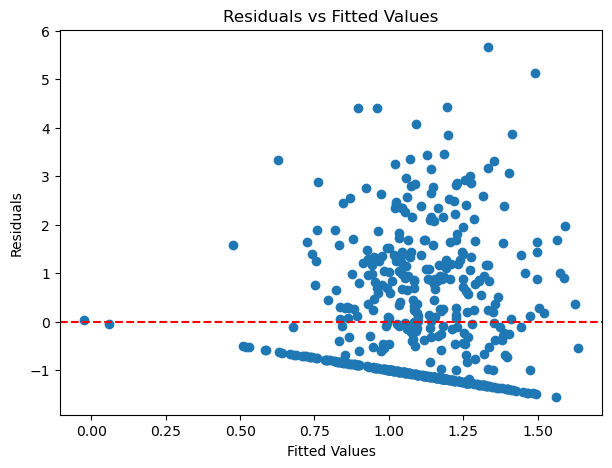

In [32]:
#  Regression Assumption
#Assumption 1: Linearity & Constant Variance
import matplotlib.pyplot as plt
fitted = model4.fittedvalues
residuals = model4.resid

plt.figure(figsize=(7,5))

plt.scatter(fitted, residuals)

plt.axhline(y=0, color="red", linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")

plt.title("Residuals vs Fitted Values")

plt.show()

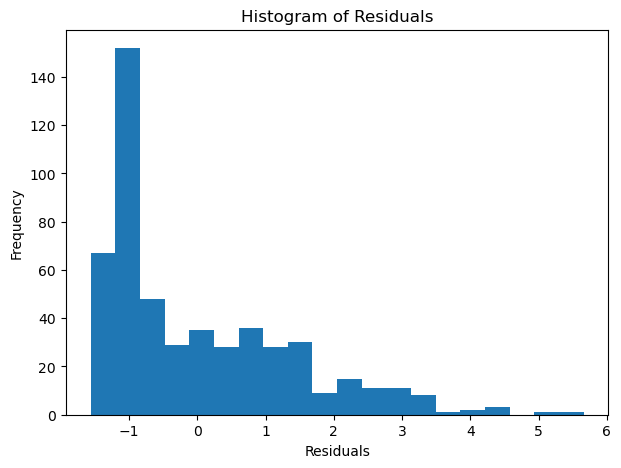

In [33]:
# Next assumption: Normality of Residuals
#Lets check whether the residuals are approximately normaly distributed 
plt.figure(figsize=(7,5))

plt.hist(model4.resid, bins=20)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")

plt.show()

In [34]:
''' The response is still not perfectly normal, therefore the residuals also remain somewhat skewed. 
The histogram of the residuals is not symmetric and exhibits a right-skewed distribution with a long positive tail. 
This indicates that the residuals are not perfectly normally distributed. 
The skewness is likely due to a small number of large burned-area observations, even after applying the log transformation.
This  is actually common with environmental datasets '''

' The response is still not perfectly normal, therefore the residuals also remain somewhat skewed. \nThe histogram of the residuals is not symmetric and exhibits a right-skewed distribution with a long positive tail. \nThis indicates that the residuals are not perfectly normally distributed. \nThe skewness is likely due to a small number of large burned-area observations, even after applying the log transformation.\nThis  is actually common with environmental datasets '

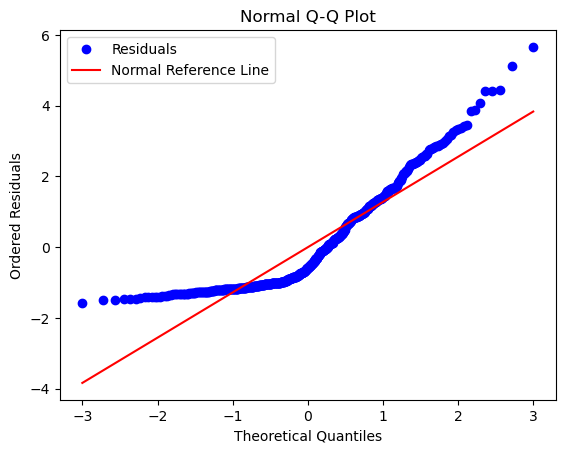

In [35]:
import scipy.stats as stats

# Create the Q-Q plot
stats.probplot(model4.resid, dist="norm", plot=plt)

# Add Legend
plt.plot([], [], 'bo', label='Residuals')           # Blue dots
plt.plot([], [], 'r-', label='Normal Reference Line')  # Red line
plt.legend()

plt.title("Normal Q-Q Plot")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Residuals")


plt.show()

In [36]:
''' 
The Q-Q plot(Quantile–Quantile Plot) shows that the residuals follow the reference line reasonably well in the center but deviate from the line in both tails, 
particularly in the upper tail. 
This indicates that the residuals are not perfectly normally distributed. 
The deviations are likely due to a small number of observations with very large burned areas, 
even after the log transformation.   '''

' \nThe Q-Q plot(Quantile–Quantile Plot) shows that the residuals follow the reference line reasonably well in the center but deviate from the line in both tails, \nparticularly in the upper tail. \nThis indicates that the residuals are not perfectly normally distributed. \nThe deviations are likely due to a small number of observations with very large burned areas, \neven after the log transformation.   '

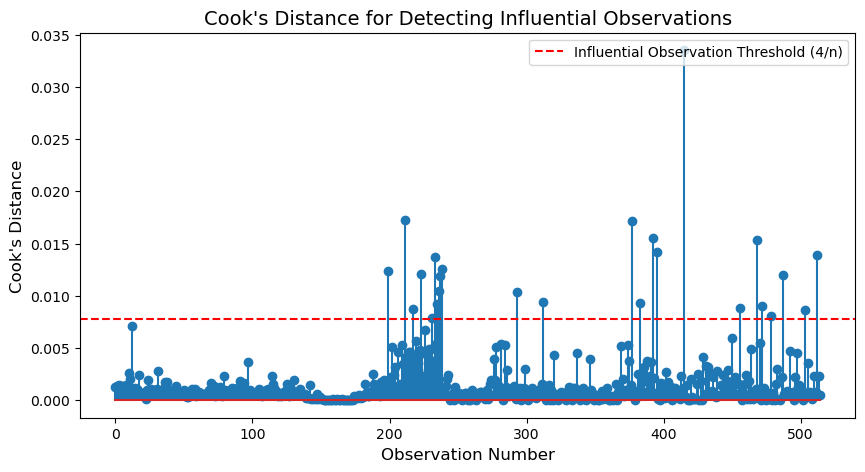

In [37]:
# Import library
from statsmodels.stats.outliers_influence import OLSInfluence
import matplotlib.pyplot as plt

# Calculate Cook's Distance
influence = OLSInfluence(model4)
cooks = influence.cooks_distance[0]

# Create the plot
plt.figure(figsize=(10,5))

plt.stem(range(len(cooks)), cooks)

# Add threshold line
plt.axhline(
    y=4/len(df),
    color="red",
    linestyle="--",
    label="Influential Observation Threshold (4/n)"
)

# Add labels and title
plt.title("Cook's Distance for Detecting Influential Observations", fontsize=14)
plt.xlabel("Observation Number", fontsize=12)
plt.ylabel("Cook's Distance", fontsize=12)

# Show legend
plt.legend(loc="upper right")

# Display plot
plt.show()

In [38]:
'''
The Cook's Distance plot indicates that most observations have low influence on the regression model, 
as their Cook's Distance values lie below the threshold (4/n). 
A small number of observations exceed the threshold, suggesting that they are potentially influential. 
These observations should be investigated further, 
but they were retained because there is no evidence that they are data errors.
'''

"\nThe Cook's Distance plot indicates that most observations have low influence on the regression model, \nas their Cook's Distance values lie below the threshold (4/n). \nA small number of observations exceed the threshold, suggesting that they are potentially influential. \nThese observations should be investigated further, \nbut they were retained because there is no evidence that they are data errors.\n"

In [39]:
import statsmodels.formula.api as smf

final_model = smf.ols(
    "log_area ~ X + Y + FFMC + DMC + DC + ISI + temp + RH + wind + rain + C(month) + C(day)",
    data=df
).fit()

final_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_area   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     1.445
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0735
Time:                        14:24:17   Log-Likelihood:                -880.17
No. Observations:                 515   AIC:                             1814.
Df Residuals:                     488   BIC:                             1929.
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          -0.4919      1.646     -0.299      0.765      -3.726       2.742
C(month)[T.aug]     0.2720      0.819      0.332      0.740      -1.337       1.881
C(month)[T.dec]     2.1904      0.794      2.758      0.006       0.630       3.751
C(month)[T.feb]     0.1842      0.558      0.330      0.741      -0.912       1.280
C(month)[T.jan]    -0.3390      1.213     -0.280      0.780      -2.721       2.043
C(month)[T.jul]     0.0845      0.711      0.119      0.905      -1.312       1.481
C(month)[T.jun]    -0.2846      0.652     -0.436      0.663      -1.566       0.997
C(month)[T.mar]    -0.3385      0.503     -0.673      0.502      -1.327       0.650
C(month)[T.may]     0.7101      1.094      0.649      0.517      -1.440       2.861
C(month)[T.oct]     0.7604      0.977      0.779      0.437      -1.159       2.679
C(month)[T.sep]     0.9361      0.918      1.020      0.308      -0.867       2.739
C(day)[T.mon]       0.1479      0.225      0.657      0.512      -0.295       0.591
C(day)[T.sat]       0.3170      0.216      1.466      0.143      -0.108       0.742
C(day)[T.sun]       0.2189      0.210      1.040      0.299      -0.195       0.632
C(day)[T.thu]       0.0825      0.239      0.345      0.730      -0.387       0.552
C(day)[T.tue]       0.3245      0.234      1.387      0.166      -0.135       0.784
C(day)[T.wed]       0.1338      0.246      0.543      0.587      -0.350       0.618
X                   0.0520      0.032      1.616      0.107      -0.011       0.115
Y                  -0.0355      0.061     -0.583      0.560      -0.155       0.084
FFMC                0.0077      0.017      0.463      0.644      -0.025       0.040
DMC                 0.0039      0.002      2.109      0.035       0.000       0.008
DC                 -0.0019      0.001     -1.494      0.136      -0.004       0.001
ISI                -0.0121      0.018     -0.674      0.501      -0.047       0.023
temp                0.0341      0.022      1.538      0.125      -0.009       0.078
RH                  0.0008      0.006      0.122      0.903      -0.011       0.013
wind                0.0565      0.038      1.476      0.141      -0.019       0.132
rain                0.0383      0.213      0.179      0.858      -0.381       0.458
==============================================================================
Omnibus:                       79.171   Durbin-Watson:                   0.936
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              112.703
Skew:                           1.091   Prob(JB):                     3.36e-25
Kurtosis:                       3.698   Cond. No.                     2.04e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly 

In [40]:
# Reduced Model 1: remove RH because it had the highest p-value in the full model

model_reduced1 = smf.ols(
    "log_area ~ X + Y + FFMC + DMC + DC + ISI + temp + wind + rain + C(month) + C(day)",
    data=df
).fit()

print("Reduced Model 1: Full model after removing RH")
print(model_reduced1.summary())

Reduced Model 1: Full model after removing RH
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     1.505
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0565
Time:                        14:56:00   Log-Likelihood:                -880.18
No. Observations:                 515   AIC:                             1812.
Df Residuals:                     489   BIC:                             1923.
Df Model:                          25                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------

In [41]:
# Reduced Model 2: remove RH and rain

model_reduced2 = smf.ols(
    "log_area ~ X + Y + FFMC + DMC + DC + ISI + temp + wind + C(month) + C(day)",
    data=df
).fit()

print("Reduced Model 2: After removing RH and rain")
print(model_reduced2.summary())

Reduced Model 2: After removing RH and rain
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.071
Model:                            OLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     1.569
Date:                Thu, 09 Jul 2026   Prob (F-statistic):             0.0428
Time:                        14:58:09   Log-Likelihood:                -880.20
No. Observations:                 515   AIC:                             1810.
Df Residuals:                     490   BIC:                             1917.
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

In [ ]:
''' 
The overall regression model is statistically significant (F-test p = 0.0428),
indicating that at least one predictor is associated with the log-transformed burned area. 
However, only a few individual predictors (such as DMC, temperature, and December relative to the reference month) 
are statistically significant based on their individual t-tests.

'''

In [42]:
#Part G

df[["X","Y","FFMC","DMC","DC","ISI","temp","wind"]].mean()

X         4.660194
Y         4.295146
FFMC     90.664272
DMC     110.925437
DC      548.626019
ISI       9.039417
temp     18.888738
wind      4.015728
dtype: float64

In [47]:
# Qualitative predictors are set to the most frequent category

df["month"].value_counts()

aug    183
sep    172
mar     54
jul     32
feb     20
jun     17
oct     15
apr      9
dec      9
jan      2
may      2
Name: month, dtype: int64

In [48]:
df["day"].value_counts()

sun    95
fri    85
sat    84
mon    74
tue    63
thu    61
wed    53
Name: day, dtype: int64

In [51]:
# Part (g): Create a new observation using sample means and most frequent categories

new_data = pd.DataFrame({
    "X": [4.660194],
    "Y": [4.295146],
    "FFMC": [90.664272],
    "DMC": [110.925437],
    "DC": [548.626019],
    "ISI": [9.039417],
    "temp": [18.888738],
    "wind": [4.015728],
    "month": ["aug"],
    "day": ["sun"]
})

print(new_data)

          X         Y       FFMC         DMC          DC       ISI       temp  \
0  4.660194  4.295146  90.664272  110.925437  548.626019  9.039417  18.888738   

       wind month  day  
0  4.015728   aug  sun  


In [53]:
# Predict log(area + 1)

predicted_log_area = model_reduced2.predict(new_data)

print("Predicted log(area + 1):")
print(predicted_log_area)

Predicted log(area + 1):
0    0.988268
dtype: float64


In [54]:
import numpy as np

predicted_area = np.exp(predicted_log_area) - 1

print("Predicted Burned Area (ha):")
print(predicted_area)

Predicted Burned Area (ha):
0    1.686578
dtype: float64


In [55]:
# Part (G): Step 1 - Identify influential observations using Cook's Distance

from statsmodels.stats.outliers_influence import OLSInfluence

# Calculate Cook's Distance
influence = OLSInfluence(model_reduced2)
cooks = influence.cooks_distance[0]

# Threshold for influential observations
threshold = 4 / len(df)

# Find influential observations
influential_points = df.index[cooks > threshold]

print("Cook's Distance Threshold:", threshold)
print("Number of Influential Observations:", len(influential_points))
print("Influential Observation Indices:")
print(influential_points.tolist())

Cook's Distance Threshold: 0.007766990291262136
Number of Influential Observations: 27
Influential Observation Indices:
[22, 104, 196, 210, 211, 223, 226, 229, 233, 235, 236, 237, 238, 293, 304, 377, 379, 395, 415, 444, 456, 468, 470, 472, 478, 503, 512]


In [56]:
# Part (G: Step 2 - Remove influential observations

df_no_outliers = df.drop(index=influential_points)

print("Original Number of Observations:", len(df))
print("Number After Removing Influential Observations:", len(df_no_outliers))

Original Number of Observations: 515
Number After Removing Influential Observations: 488


In [57]:
# Part (h): Step 3 - Refit the final model after removing influential observations

model_no_outliers = smf.ols(
    "log_area ~ X + Y + FFMC + DMC + DC + ISI + temp + wind + C(month) + C(day)",
    data=df_no_outliers
).fit()

print("Part (h): Model After Removing Influential Observations")
print(model_no_outliers.summary())

Part (h): Model After Removing Influential Observations
                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.043
Method:                 Least Squares   F-statistic:                     1.997
Date:                Thu, 09 Jul 2026   Prob (F-statistic):            0.00490
Time:                        17:21:49   Log-Likelihood:                -757.97
No. Observations:                 488   AIC:                             1562.
Df Residuals:                     465   BIC:                             1658.
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------

In [58]:
# Part (h): Step 4 - Compare original model and model without influential observations

comparison = pd.DataFrame({
    "Statistic": ["R-squared", "Adjusted R-squared", "AIC", "BIC"],
    "Original Model": [
        model_reduced2.rsquared,
        model_reduced2.rsquared_adj,
        model_reduced2.aic,
        model_reduced2.bic
    ],
    "Model Without Influential Observations": [
        model_no_outliers.rsquared,
        model_no_outliers.rsquared_adj,
        model_no_outliers.aic,
        model_no_outliers.bic
    ]
})

print("Part (h): Model Comparison")
print(comparison)

Part (h): Model Comparison
            Statistic  Original Model  Model Without Influential Observations
0           R-squared        0.071383                                0.086319
1  Adjusted R-squared        0.025900                                0.043091
2                 AIC     1810.398767                             1561.943160
3                 BIC     1916.502940                             1658.320414
